# EM Volume Exploration

**Author:** Kevin Druciak (kevintdruciak@gmail.com)

Loading, inspecting, and visualizing the ISBI 2012 *Drosophila* serial-section TEM dataset. This notebook covers the data exploration stage of the connectomics pipeline -- understanding volume geometry, intensity distributions, and spatial structure before segmentation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from skimage.io import imread

## Load ISBI 2012 Dataset

30-slice serial section TEM of *Drosophila* first instar larva ventral nerve cord. 512x512 pixels per slice, ~4x4x50 nm voxel resolution.

In [2]:
volume = imread("../sample_data/isbi2012/train-volume.tif")
labels = imread("../sample_data/isbi2012/train-labels.tif")

voxel_size_nm = np.array([50.0, 4.0, 4.0])  # Z, Y, X in nanometers

print(f"Volume shape: {volume.shape}")
print(f"Dtype: {volume.dtype}")
print(f"Intensity range: [{volume.min()}, {volume.max()}]")
print(f"Voxel size: {voxel_size_nm} nm (Z, Y, X)")
print(f"Physical extent: {volume.shape * voxel_size_nm / 1000} \u03bcm")
print(f"Labels shape: {labels.shape}")
print(f"Labels unique values: {np.unique(labels)}")

Volume shape: (30, 512, 512)
Dtype: uint8
Intensity range: [0, 255]
Voxel size: [50.  4.  4.] nm (Z, Y, X)
Physical extent: [1.5   2.048 2.048] μm
Labels shape: (30, 512, 512)
Labels unique values: [  0 255]


## Orthogonal Slices

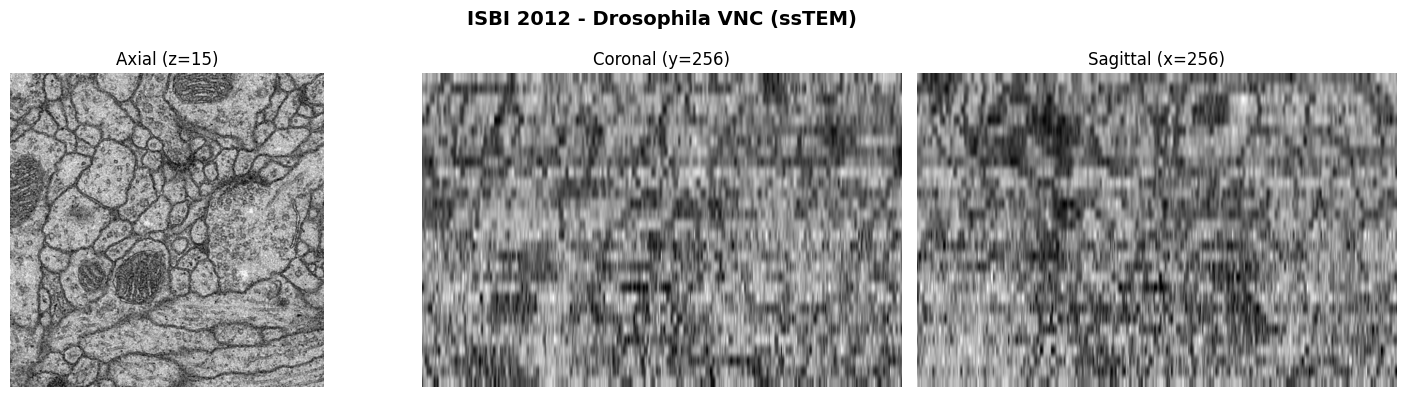

In [3]:
z, y, x = [s // 2 for s in volume.shape]

fig = plt.figure(figsize=(15, 4))
gs = GridSpec(1, 3, figure=fig)

for i, (slc, label) in enumerate([
    (volume[z, :, :], f"Axial (z={z})"),
    (volume[:, y, :], f"Coronal (y={y})"),
    (volume[:, :, x], f"Sagittal (x={x})"),
]):
    ax = fig.add_subplot(gs[0, i])
    ax.imshow(slc, cmap="gray", aspect="auto" if i > 0 else "equal")
    ax.set_title(label)
    ax.axis("off")

fig.suptitle("ISBI 2012 - Drosophila VNC (ssTEM)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## EM Slice with Ground Truth Overlay

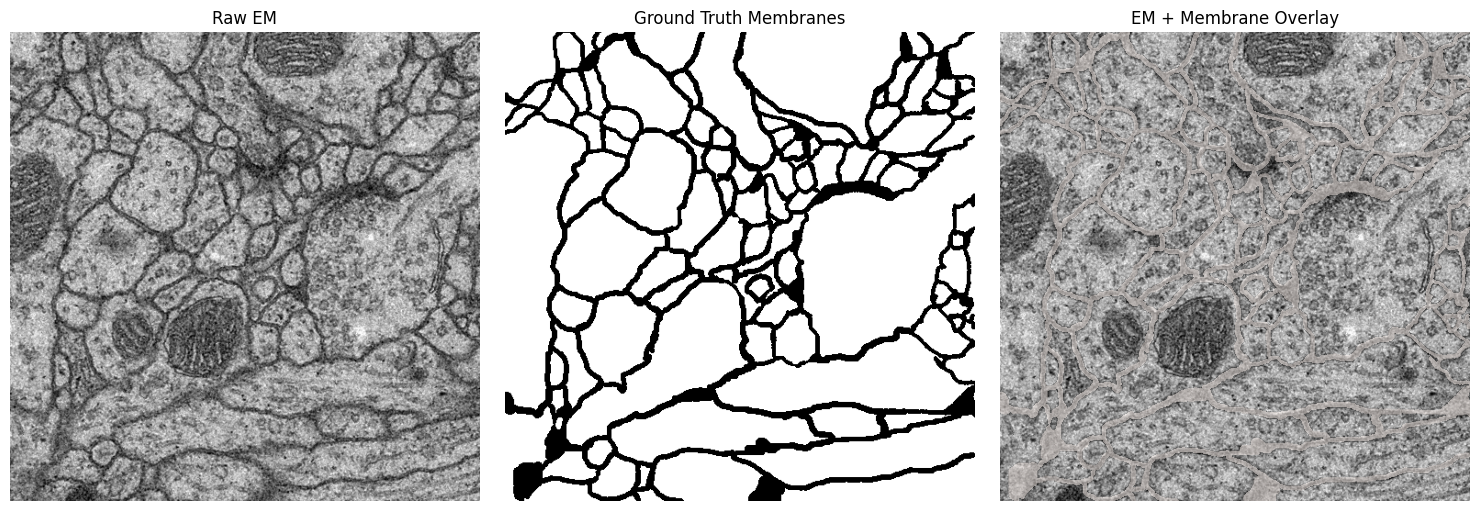

In [4]:
mid_z = volume.shape[0] // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(volume[mid_z], cmap="gray")
axes[0].set_title("Raw EM")
axes[0].axis("off")

axes[1].imshow(labels[mid_z], cmap="gray")
axes[1].set_title("Ground Truth Membranes")
axes[1].axis("off")

axes[2].imshow(volume[mid_z], cmap="gray")
membrane_overlay = np.ma.masked_where(labels[mid_z] > 128, labels[mid_z])
axes[2].imshow(membrane_overlay, cmap="Reds", alpha=0.5)
axes[2].set_title("EM + Membrane Overlay")
axes[2].axis("off")

plt.tight_layout()
plt.show()

## Intensity Histogram

The bimodal distribution is characteristic of EM tissue: a dark peak (membranes/boundaries) and a bright peak (cell interiors/cytoplasm).

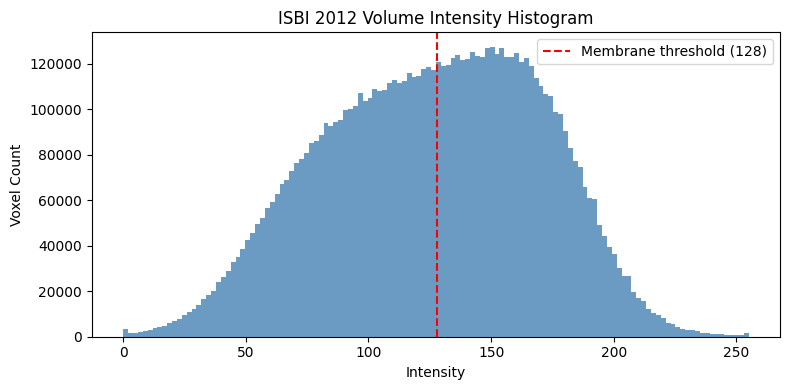

Mean: 126.2  Std: 44.0  Median: 129.0


In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(volume.ravel(), bins=128, color="steelblue", edgecolor="none", alpha=0.8)
ax.set_xlabel("Intensity")
ax.set_ylabel("Voxel Count")
ax.set_title("ISBI 2012 Volume Intensity Histogram")
ax.axvline(x=128, color="red", linestyle="--", label="Membrane threshold (128)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Mean: {volume.mean():.1f}  Std: {volume.std():.1f}  Median: {np.median(volume):.1f}")

## Slice Montage

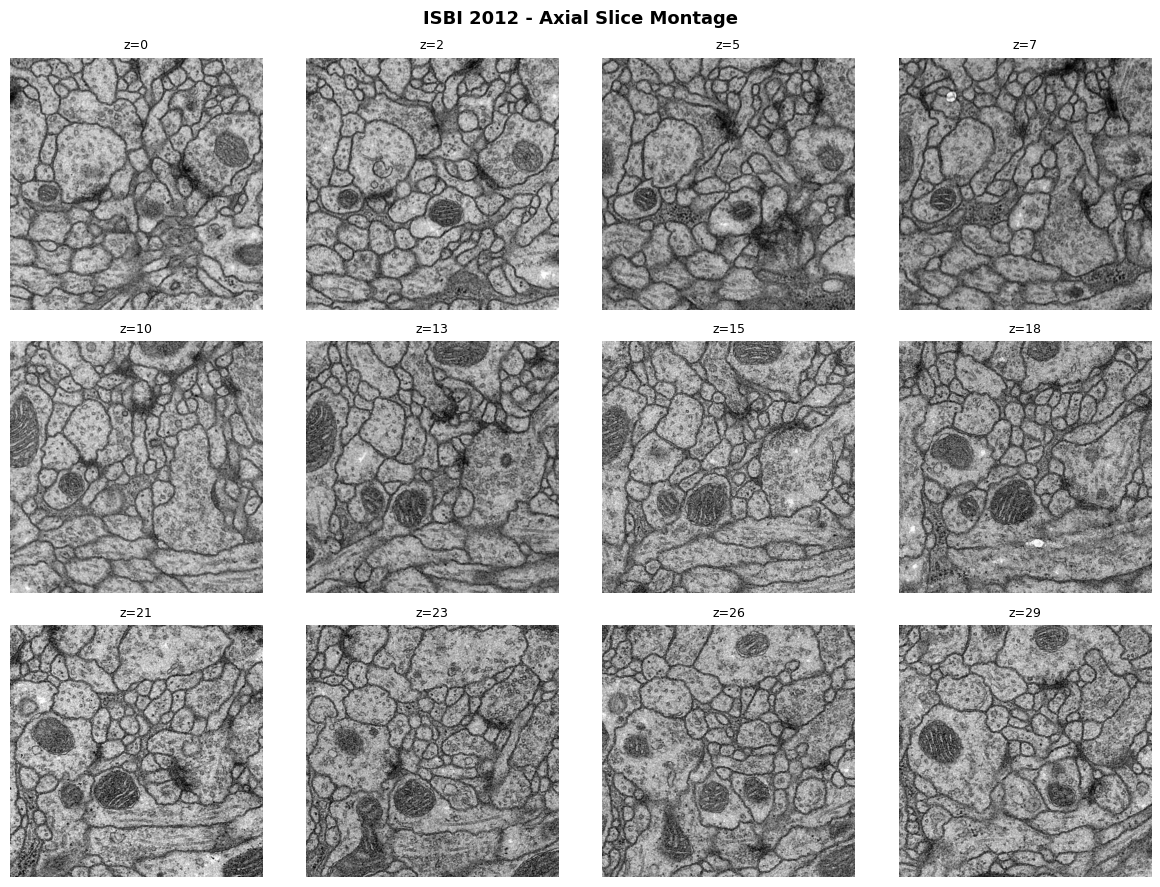

In [6]:
n_slices = min(12, volume.shape[0])
indices = np.linspace(0, volume.shape[0] - 1, n_slices, dtype=int)
cols = 4
rows = int(np.ceil(n_slices / cols))

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = axes.flatten()

for i, idx in enumerate(indices):
    axes[i].imshow(volume[idx], cmap="gray")
    axes[i].set_title(f"z={idx}", fontsize=9)
    axes[i].axis("off")

for j in range(i + 1, len(axes)):
    axes[j].axis("off")

fig.suptitle("ISBI 2012 - Axial Slice Montage", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()